In [4]:
import numpy as np 
import pandas as pd 
df=pd.read_csv("data.csv")

In [5]:
import pandas as pd

# load dataset
df = pd.read_csv("data.csv")

# category columns
categories = ["Food", "Fuel", "Rent", "Transport", "Utilities", "Entertainment"]

# create total cost column
df["Total_Cost"] = df[categories].sum(axis=1)

# sort data
df = df.sort_values(["City", "Year"])

In [6]:
summary = []

for city, group in df.groupby("City"):
    start_year = group.iloc[0]["Year"]
    end_year = group.iloc[-1]["Year"]
    
    start_total = group.iloc[0]["Total_Cost"]
    end_total = group.iloc[-1]["Total_Cost"]
    
    summary.append({
        "City": city,
        "Start_Year": start_year,
        "End_Year": end_year,
        "Start_Total": start_total,
        "End_Total": end_total
    })

summary_df = pd.DataFrame(summary)

print(summary_df)

     City  Start_Year  End_Year  Start_Total  End_Total
0   Delhi        2018      2024        15673      24973
1  Mumbai        2018      2024        18180      27685
2    Pune        2018      2024        12865      20463


In [7]:
latest_year = df["Year"].max()

latest_df = df[df["Year"] == latest_year][["City", "Total_Cost"]]

print(latest_df)

      City  Total_Cost
20   Delhi       24973
6   Mumbai       27685
13    Pune       20463


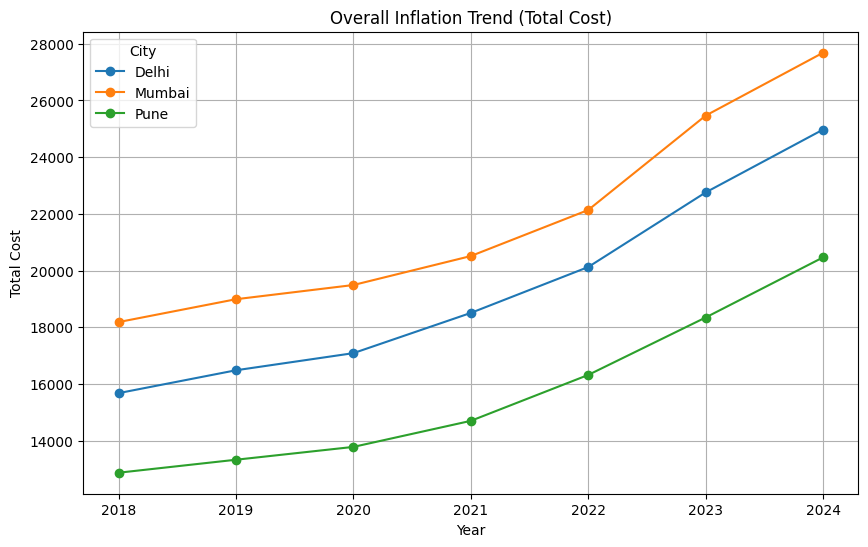

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

for city, group in df.groupby("City"):
    plt.plot(group["Year"], group["Total_Cost"], marker='o', label=city)

plt.title("Overall Inflation Trend (Total Cost)")
plt.xlabel("Year")
plt.ylabel("Total Cost")
plt.legend(title="City")
plt.grid(True)

plt.show()

In [10]:
import pandas as pd
import matplotlib.pyplot as plt



categories = ["Food", "Fuel", "Rent", "Transport", "Utilities", "Entertainment"]

# sort data
df = df.sort_values(["City", "Year"])

In [11]:
latest_year = df["Year"].max()

latest_df = df[df["Year"] == latest_year]

print(latest_df)

    Year    City  Food  Fuel   Rent  Transport  Utilities  Entertainment  \
20  2024   Delhi   155   118  16000       2900       3400           2400   
6   2024  Mumbai   165   120  18000       3200       3600           2600   
13  2024    Pune   145   118  13000       2300       2800           2100   

    Total_Cost  
20       24973  
6        27685  
13       20463  


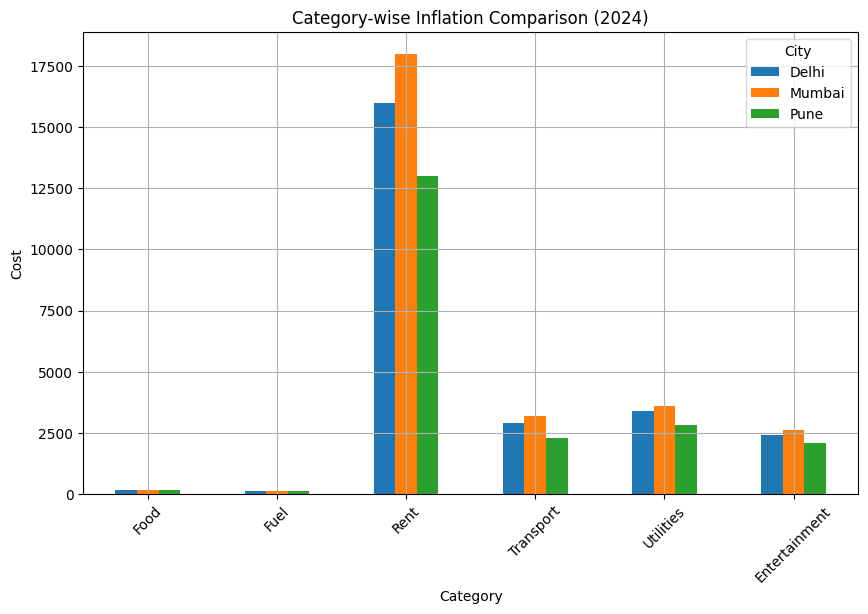

In [12]:
plot_data = latest_df.set_index("City")[categories]

plot_data.T.plot(kind="bar", figsize=(10,6))

plt.title(f"Category-wise Inflation Comparison ({latest_year})")
plt.xlabel("Category")
plt.ylabel("Cost")
plt.xticks(rotation=45)
plt.grid(True)
plt.legend(title="City")

plt.show()

In [14]:
import pandas as pd
import matplotlib.pyplot as plt



categories = ["Food", "Fuel", "Rent", "Transport", "Utilities", "Entertainment"]

# create total cost
df["Total_Cost"] = df[categories].sum(axis=1)

# sort properly
df = df.sort_values(["City", "Year"])

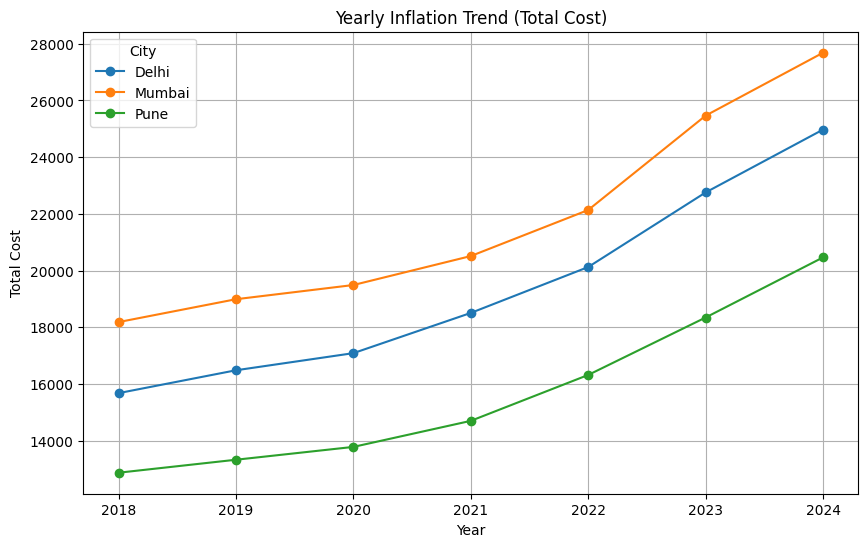

In [15]:
plt.figure(figsize=(10,6))

for city, group in df.groupby("City"):
    plt.plot(group["Year"], group["Total_Cost"], marker='o', label=city)

plt.title("Yearly Inflation Trend (Total Cost)")
plt.xlabel("Year")
plt.ylabel("Total Cost")
plt.legend(title="City")
plt.grid(True)

plt.show()

In [17]:
import pandas as pd



categories = ["Food", "Fuel", "Rent", "Transport", "Utilities", "Entertainment"]

# total cost
df["Total_Cost"] = df[categories].sum(axis=1)

# sort data
df = df.sort_values(["City", "Year"])

In [18]:
latest_year = df["Year"].max()

latest_df = df[df["Year"] == latest_year][["City", "Total_Cost"]]

In [19]:
leaderboard = latest_df.sort_values("Total_Cost", ascending=False).reset_index(drop=True)

# add rank
leaderboard.index = leaderboard.index + 1
leaderboard["Rank"] = leaderboard.index

# rearrange
leaderboard = leaderboard[["Rank", "City", "Total_Cost"]]

print(leaderboard)

   Rank    City  Total_Cost
1     1  Mumbai       27685
2     2   Delhi       24973
3     3    Pune       20463


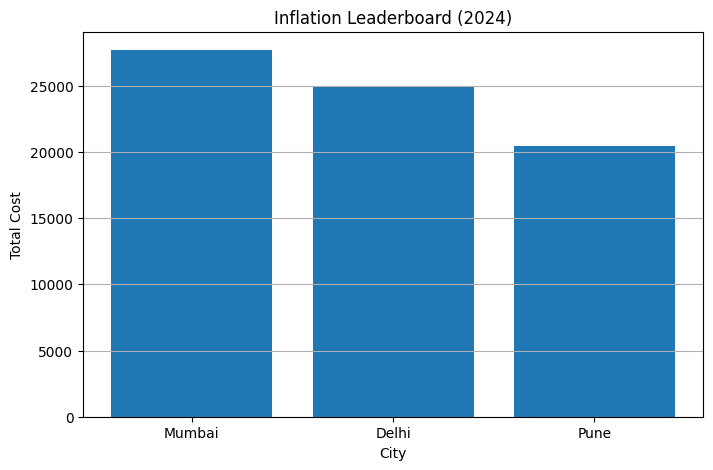

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(leaderboard["City"], leaderboard["Total_Cost"])

plt.title(f"Inflation Leaderboard ({latest_year})")
plt.xlabel("City")
plt.ylabel("Total Cost")
plt.grid(axis='y')

plt.show()

In [22]:
import pandas as pd



categories = ["Food", "Fuel", "Rent", "Transport", "Utilities", "Entertainment"]

# total cost
df["Total_Cost"] = df[categories].sum(axis=1)

# sort
df = df.sort_values(["City", "Year"])

In [23]:
stability_df = df.groupby("City")["Total_Cost"].std().reset_index()

stability_df.columns = ["City", "Fluctuation"]

print(stability_df)

     City  Fluctuation
0   Delhi  3450.029876
1  Mumbai  3563.735721
2    Pune  2841.408730


In [24]:
stability_df = stability_df.sort_values("Fluctuation")

stability_df.index = stability_df.index + 1
stability_df["Rank"] = stability_df.index

print(stability_df)

     City  Fluctuation  Rank
3    Pune  2841.408730     3
1   Delhi  3450.029876     1
2  Mumbai  3563.735721     2


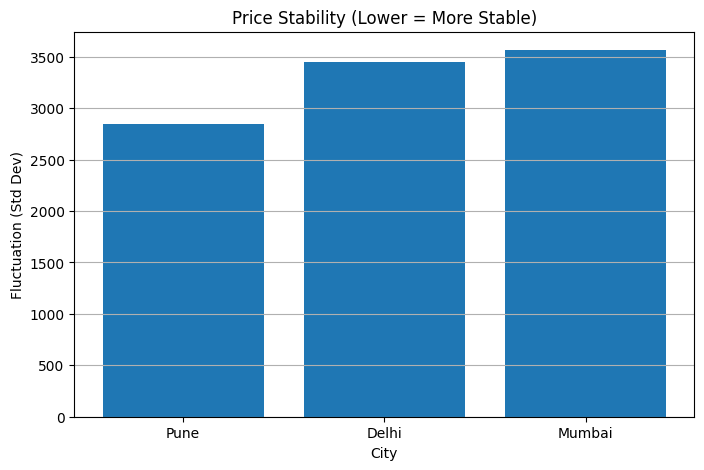

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(stability_df["City"], stability_df["Fluctuation"])

plt.title("Price Stability (Lower = More Stable)")
plt.xlabel("City")
plt.ylabel("Fluctuation (Std Dev)")
plt.grid(axis='y')

plt.show()

In [ ]:
# ═══════════════════════════════════════════════════
# Export data to JSON for the Frontend Dashboard
# ═══════════════════════════════════════════════════
import json, os

OUT_DIR = "modern-dashboard/public"
os.makedirs(OUT_DIR, exist_ok=True)

# Latest-year category comparison
cols = ["City","Food","Fuel","Rent","Transport","Utilities","Entertainment","Total_Cost"]
latest_df[cols].to_json(os.path.join(OUT_DIR, "inflation_data.json"), orient="records", indent=2)

print("✅ inflation.ipynb → exported inflation_data.json")
